In [1]:
# ============================================================
# Test 1. Basic output / metadata check
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

OUT_ROOT = Path(r"E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1")

print("========== Output root check ==========")
print("OUT_ROOT exists:", OUT_ROOT.exists())
print("OUT_ROOT:", OUT_ROOT)

required_files = [
    OUT_ROOT / "metadata_slices.csv",
    OUT_ROOT / "metadata_organs.csv",
    OUT_ROOT / "selected_patients.csv",
    OUT_ROOT / "final_preprocess_config.json",
]

print("\n========== Required files ==========")
for p in required_files:
    print(p.name, ":", p.exists(), "|", p)

error_path = OUT_ROOT / "preprocess_errors.csv"
print("\npreprocess_errors.csv exists:", error_path.exists())

if error_path.exists():
    err_df = pd.read_csv(error_path)
    print("error rows:", len(err_df))
    display(err_df)
else:
    print("No error file. Good.")

slice_df = pd.read_csv(OUT_ROOT / "metadata_slices.csv")
organ_df = pd.read_csv(OUT_ROOT / "metadata_organs.csv")
selected_df = pd.read_csv(OUT_ROOT / "selected_patients.csv")

print("\n========== Metadata row counts ==========")
print("selected patients:", len(selected_df))
print("slice rows:", len(slice_df))
print("organ rows:", len(organ_df))

print("\n========== Patient list ==========")
display(selected_df)

print("\n========== Slice count by patient ==========")
display(slice_df.groupby("patient_id").size())

print("\n========== Organ count by patient ==========")
display(organ_df.groupby("patient_id").size())

print("\n========== Metadata columns ==========")
print("slice_df columns:")
print(slice_df.columns.tolist())

print("\norgan_df columns:")
print(organ_df.columns.tolist())

========== Output root check ==========
OUT_ROOT exists: True
OUT_ROOT: E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1

========== Required files ==========
metadata_slices.csv : True | E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1\metadata_slices.csv
metadata_organs.csv : True | E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1\metadata_organs.csv
selected_patients.csv : True | E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1\selected_patients.csv
final_preprocess_config.json : True | E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1\final_preprocess_config.json

preprocess_errors.csv exists: False
No error file. Good.

========== Metadata row counts ==========
selected patients: 5
slice rows: 1430
organ rows: 100

========== Patient list ==========


,patient_id,patient_dir,dcm_count
0,normal015,E:\jyp\ct_data_2d\Normal Cases\normal015,145
1,normal004,E:\jyp\ct_data_2d\Normal Cases\normal004,128
2,normal036,E:\jyp\ct_data_2d\Normal Cases\normal036,159
3,normal032,E:\jyp\ct_data_2d\Normal Cases\normal032,146
4,normal029,E:\jyp\ct_data_2d\Normal Cases\normal029,137



========== Slice count by patient ==========


patient_id
normal004    256
normal015    290
normal029    274
normal032    292
normal036    318
dtype: int64


========== Organ count by patient ==========


patient_id
normal004    20
normal015    20
normal029    20
normal032    20
normal036    20
dtype: int64


========== Metadata columns ==========
slice_df columns:
['group', 'patient_id', 'patient_dir', 'slice_index', 'slice_png', 'lung_png', 'organ_exclusion_png', 'pure_lung_png', 'overlay_png', 'refined_lung_area', 'organ_exclusion_area', 'pure_lung_area', 'refined_lung_area_ratio', 'organ_exclusion_area_ratio', 'pure_lung_area_ratio', 'nearest_original_slice_index', 'nearest_original_z_physical', 'distance_to_original_slice_mm', 'is_original_slice', 'ct_native_lps_nii', 'ct_1mm_lps_nii', 'lung_refined_1mm_nii', 'organ_exclusion_1mm_nii', 'pure_lung_1mm_nii', 'organ_mask_dir', 'used_organs_for_exclusion', 'raw_size', 'raw_spacing', 'one_mm_size', 'one_mm_spacing']

organ_df columns:
['organ_name', 'organ_mask_1mm_nii', 'voxel_count', 'group', 'patient_id', 'patient_dir']


In [2]:
# ============================================================
# Test 2. NIfTI grid consistency check
# ============================================================

import SimpleITK as sitk
from pathlib import Path
import pandas as pd
import numpy as np

OUT_ROOT = Path(r"E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1")

slice_df = pd.read_csv(OUT_ROOT / "metadata_slices.csv")
organ_df = pd.read_csv(OUT_ROOT / "metadata_organs.csv")

def read_img_info(path):
    img = sitk.ReadImage(str(path))
    arr = sitk.GetArrayFromImage(img)
    return {
        "img": img,
        "arr": arr,
        "size": img.GetSize(),
        "spacing": img.GetSpacing(),
        "origin": img.GetOrigin(),
        "direction": img.GetDirection(),
        "shape": arr.shape,
        "dtype": arr.dtype,
        "min": float(np.nanmin(arr)),
        "max": float(np.nanmax(arr)),
        "nan_count": int(np.isnan(arr).sum()) if np.issubdtype(arr.dtype, np.floating) else 0,
    }

grid_rows = []
problem_rows = []

for patient_id in sorted(slice_df["patient_id"].unique()):
    pdf = slice_df[slice_df["patient_id"] == patient_id]
    first = pdf.iloc[0]

    paths = {
        "ct_1mm": Path(first["ct_1mm_lps_nii"]),
        "lung_refined": Path(first["lung_refined_1mm_nii"]),
        "organ_exclusion": Path(first["organ_exclusion_1mm_nii"]),
        "pure_lung": Path(first["pure_lung_1mm_nii"]),
    }

    print("\n" + "=" * 80)
    print("Patient:", patient_id)

    infos = {}

    for name, p in paths.items():
        exists = p.exists()
        print(name, "exists:", exists, "|", p)

        if not exists:
            problem_rows.append({
                "patient_id": patient_id,
                "problem": f"{name} file missing",
                "path": str(p),
            })
            continue

        infos[name] = read_img_info(p)

        print(
            name,
            "size:", infos[name]["size"],
            "spacing:", infos[name]["spacing"],
            "shape:", infos[name]["shape"],
            "dtype:", infos[name]["dtype"],
            "min/max:", infos[name]["min"], infos[name]["max"],
        )

    if "ct_1mm" not in infos:
        continue

    ct_info = infos["ct_1mm"]

    for name in ["lung_refined", "organ_exclusion", "pure_lung"]:
        if name not in infos:
            continue

        same_size = infos[name]["size"] == ct_info["size"]
        same_spacing = np.allclose(infos[name]["spacing"], ct_info["spacing"])
        same_origin = np.allclose(infos[name]["origin"], ct_info["origin"])
        same_direction = np.allclose(infos[name]["direction"], ct_info["direction"])

        grid_rows.append({
            "patient_id": patient_id,
            "mask_name": name,
            "same_size": same_size,
            "same_spacing": same_spacing,
            "same_origin": same_origin,
            "same_direction": same_direction,
            "ct_size": str(ct_info["size"]),
            "mask_size": str(infos[name]["size"]),
            "ct_spacing": str(ct_info["spacing"]),
            "mask_spacing": str(infos[name]["spacing"]),
        })

        if not (same_size and same_spacing and same_origin and same_direction):
            problem_rows.append({
                "patient_id": patient_id,
                "problem": f"{name} grid mismatch",
                "path": str(paths[name]),
            })

grid_df = pd.DataFrame(grid_rows)
problem_df = pd.DataFrame(problem_rows)

print("\n========== Grid consistency summary ==========")
display(grid_df)

print("\n========== Problems ==========")
if len(problem_df) == 0:
    print("[OK] No grid mismatch or missing core NIfTI files.")
else:
    display(problem_df)


Patient: normal004
ct_1mm exists: True | E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1\ct_1mm_lps\Normal\normal004_1mm_lps.nii.gz
ct_1mm size: (512, 512, 256) spacing: (0.6640625, 0.6640625, 1.0) shape: (256, 512, 512) dtype: int16 min/max: -1024.0 1567.0
lung_refined exists: True | E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1\lung_masks_refined_1mm\Normal\normal004\lung_refined_1mm.nii.gz
lung_refined size: (512, 512, 256) spacing: (0.6640625, 0.6640625, 1.0) shape: (256, 512, 512) dtype: uint8 min/max: 0.0 1.0
organ_exclusion exists: True | E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1\organ_exclusion_1mm\Normal\normal004\organ_exclusion_1mm.nii.gz
organ_exclusion size: (512, 512, 256) spacing: (0.6640625, 0.6640625, 1.0) shape: (256, 512, 512) dtype: uint8 min/max: 0.0 1.0
pure_lung exists: True | E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1\pure_lung_1mm\Normal\normal004\pure_lung_1mm.nii.gz
pure_lung size: (512, 512, 256) spacing: (0.6640625, 0.66406

,patient_id,mask_name,same_size,same_spacing,same_origin,same_direction,ct_size,mask_size,ct_spacing,mask_spacing
0,normal004,lung_refined,True,True,True,True,"(512, 512, 256)","(512, 512, 256)","(0.6640625, 0.6640625, 1.0)","(0.6640625, 0.6640625, 1.0)"
1,normal004,organ_exclusion,True,True,True,True,"(512, 512, 256)","(512, 512, 256)","(0.6640625, 0.6640625, 1.0)","(0.6640625, 0.6640625, 1.0)"
2,normal004,pure_lung,True,True,True,True,"(512, 512, 256)","(512, 512, 256)","(0.6640625, 0.6640625, 1.0)","(0.6640625, 0.6640625, 1.0)"
3,normal015,lung_refined,True,True,True,True,"(512, 512, 290)","(512, 512, 290)","(0.6875, 0.6875, 1.0)","(0.6875, 0.6875, 1.0)"
4,normal015,organ_exclusion,True,True,True,True,"(512, 512, 290)","(512, 512, 290)","(0.6875, 0.6875, 1.0)","(0.6875, 0.6875, 1.0)"
5,normal015,pure_lung,True,True,True,True,"(512, 512, 290)","(512, 512, 290)","(0.6875, 0.6875, 1.0)","(0.6875, 0.6875, 1.0)"
6,normal029,lung_refined,True,True,True,True,"(512, 512, 274)","(512, 512, 274)","(0.71484375, 0.71484375, 1.0)","(0.71484375, 0.71484375, 1.0)"
7,normal029,organ_exclusion,True,True,True,True,"(512, 512, 274)","(512, 512, 274)","(0.71484375, 0.71484375, 1.0)","(0.71484375, 0.71484375, 1.0)"
8,normal029,pure_lung,True,True,True,True,"(512, 512, 274)","(512, 512, 274)","(0.71484375, 0.71484375, 1.0)","(0.71484375, 0.71484375, 1.0)"
9,normal032,lung_refined,True,True,True,True,"(512, 512, 292)","(512, 512, 292)","(0.58984375, 0.58984375, 1.0)","(0.58984375, 0.58984375, 1.0)"



========== Problems ==========
[OK] No grid mismatch or missing core NIfTI files.


In [3]:
# ============================================================
# Test 3. Pure lung logic check
# ============================================================

import SimpleITK as sitk
import numpy as np
import pandas as pd
from pathlib import Path

OUT_ROOT = Path(r"E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1")
slice_df = pd.read_csv(OUT_ROOT / "metadata_slices.csv")

logic_rows = []

for patient_id in sorted(slice_df["patient_id"].unique()):
    first = slice_df[slice_df["patient_id"] == patient_id].iloc[0]

    lung_path = Path(first["lung_refined_1mm_nii"])
    organ_path = Path(first["organ_exclusion_1mm_nii"])
    pure_path = Path(first["pure_lung_1mm_nii"])

    lung = sitk.GetArrayFromImage(sitk.ReadImage(str(lung_path))) > 0
    organ = sitk.GetArrayFromImage(sitk.ReadImage(str(organ_path))) > 0
    pure_saved = sitk.GetArrayFromImage(sitk.ReadImage(str(pure_path))) > 0

    pure_expected = lung & (~organ)

    mismatch = pure_saved ^ pure_expected
    mismatch_count = int(mismatch.sum())

    lung_count = int(lung.sum())
    organ_count = int(organ.sum())
    pure_count = int(pure_saved.sum())

    organ_inside_lung = int((organ & lung).sum())
    removed_from_lung = int((lung & organ).sum())

    logic_rows.append({
        "patient_id": patient_id,
        "lung_voxels": lung_count,
        "organ_exclusion_voxels": organ_count,
        "organ_inside_lung_voxels": organ_inside_lung,
        "pure_lung_voxels": pure_count,
        "removed_from_lung_voxels": removed_from_lung,
        "pure_logic_mismatch_voxels": mismatch_count,
        "pure_logic_ok": mismatch_count == 0,
    })

logic_df = pd.DataFrame(logic_rows)

print("========== Pure lung logic check ==========")
display(logic_df)

if logic_df["pure_logic_ok"].all():
    print("[OK] pure_lung = refined_lung & ~organ_exclusion logic is correct.")
else:
    print("[WARN] pure_lung mismatch exists.")

========== Pure lung logic check ==========


,patient_id,lung_voxels,organ_exclusion_voxels,organ_inside_lung_voxels,pure_lung_voxels,removed_from_lung_voxels,pure_logic_mismatch_voxels,pure_logic_ok
0,normal004,9264966,4164020,63650,9201316,63650,0,True
1,normal015,7507735,4736088,45878,7461857,45878,0,True
2,normal029,9087578,5339836,40315,9047263,40315,0,True
3,normal032,8236584,7794466,118672,8117912,118672,0,True
4,normal036,11665114,5558046,84721,11580393,84721,0,True


[OK] pure_lung = refined_lung & ~organ_exclusion logic is correct.


In [4]:
# ============================================================
# Test 4. Valid lung slice filtering check
# ============================================================

import pandas as pd
from pathlib import Path
import numpy as np

OUT_ROOT = Path(r"E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1")
slice_df = pd.read_csv(OUT_ROOT / "metadata_slices.csv")

# 기준값은 나중에 조정 가능
MIN_PURE_LUNG_AREA_RATIO = 0.01

slice_df["is_valid_lung_slice_test"] = (
    slice_df["pure_lung_area_ratio"] >= MIN_PURE_LUNG_AREA_RATIO
).astype(int)

print("========== Valid lung slice test ==========")
print("MIN_PURE_LUNG_AREA_RATIO:", MIN_PURE_LUNG_AREA_RATIO)

display(
    slice_df
    .groupby("patient_id")["is_valid_lung_slice_test"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "valid_lung_slices", "count": "total_slices"})
)

print("\n========== pure_lung_area_ratio summary ==========")
display(slice_df["pure_lung_area_ratio"].describe())

print("\n========== Valid / invalid slice count ==========")
display(slice_df["is_valid_lung_slice_test"].value_counts())

# 저장해두기
valid_slice_path = OUT_ROOT / "metadata_slices_with_valid_lung_flag_test.csv"
slice_df.to_csv(valid_slice_path, index=False, encoding="utf-8-sig")

print("\nSaved:", valid_slice_path)

========== Valid lung slice test ==========
MIN_PURE_LUNG_AREA_RATIO: 0.01


,valid_lung_slices,total_slices
patient_id,,
normal004,238,256
normal015,259,290
normal029,247,274
normal032,240,292
normal036,273,318



========== pure_lung_area_ratio summary ==========


count    1430.000000
mean        0.121133
std         0.081930
min         0.000000
25%         0.034676
50%         0.137560
75%         0.195993
max         0.248051
Name: pure_lung_area_ratio, dtype: float64


========== Valid / invalid slice count ==========


is_valid_lung_slice_test
1    1257
0     173
Name: count, dtype: int64


Saved: E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1\metadata_slices_with_valid_lung_flag_test.csv


In [5]:
# ============================================================
# Test 5. PNG path existence check
# ============================================================

import pandas as pd
from pathlib import Path

OUT_ROOT = Path(r"E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1")
slice_df = pd.read_csv(OUT_ROOT / "metadata_slices.csv")

png_cols = [
    "slice_png",
    "lung_png",
    "organ_exclusion_png",
    "pure_lung_png",
    "overlay_png",
]

rows = []

for col in png_cols:
    exists_series = slice_df[col].apply(lambda x: Path(str(x)).exists())
    rows.append({
        "column": col,
        "exists_count": int(exists_series.sum()),
        "missing_count": int((~exists_series).sum()),
        "total": len(exists_series),
    })

png_check_df = pd.DataFrame(rows)

print("========== PNG existence check ==========")
display(png_check_df)

missing_examples = []

for col in png_cols:
    missing = slice_df[~slice_df[col].apply(lambda x: Path(str(x)).exists())]
    if len(missing) > 0:
        for _, r in missing.head(3).iterrows():
            missing_examples.append({
                "column": col,
                "patient_id": r["patient_id"],
                "slice_index": r["slice_index"],
                "path": r[col],
            })

print("\n========== Missing examples ==========")
if len(missing_examples) == 0:
    print("[OK] All PNG files exist.")
else:
    display(pd.DataFrame(missing_examples))

========== PNG existence check ==========


,column,exists_count,missing_count,total
0,slice_png,1430,0,1430
1,lung_png,1430,0,1430
2,organ_exclusion_png,1430,0,1430
3,pure_lung_png,1430,0,1430
4,overlay_png,1430,0,1430



========== Missing examples ==========
[OK] All PNG files exist.


Selected patient: normal015
Selected slice indices: [165, 190, 218, 51, 263]


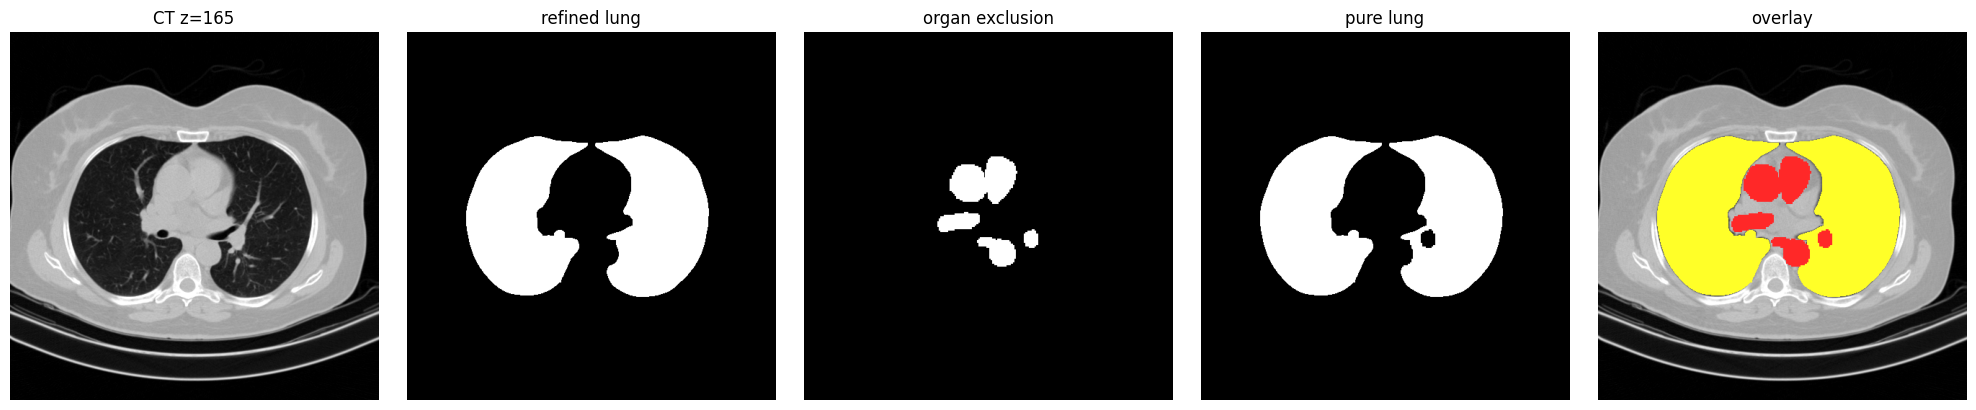

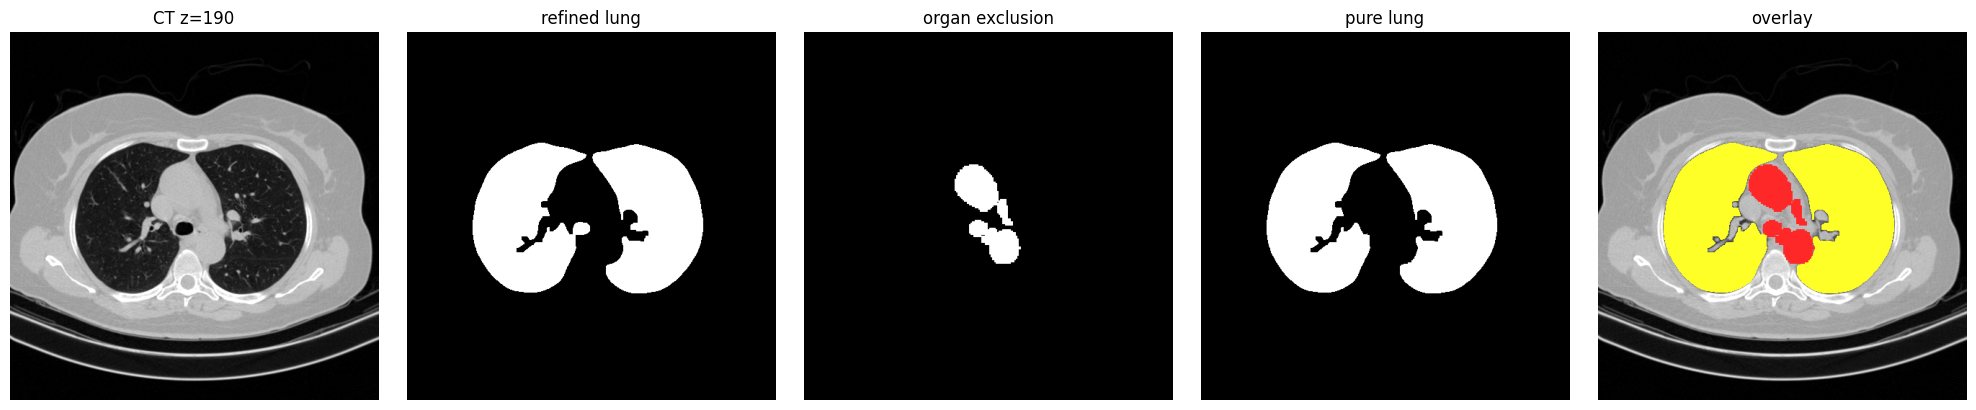

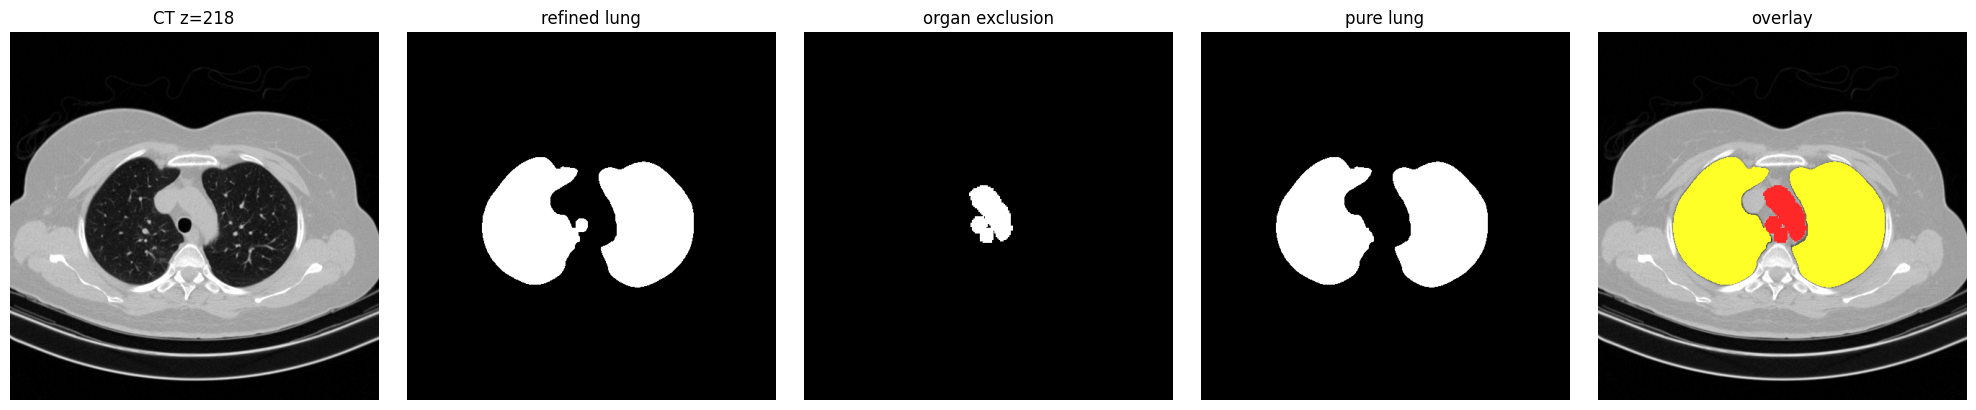

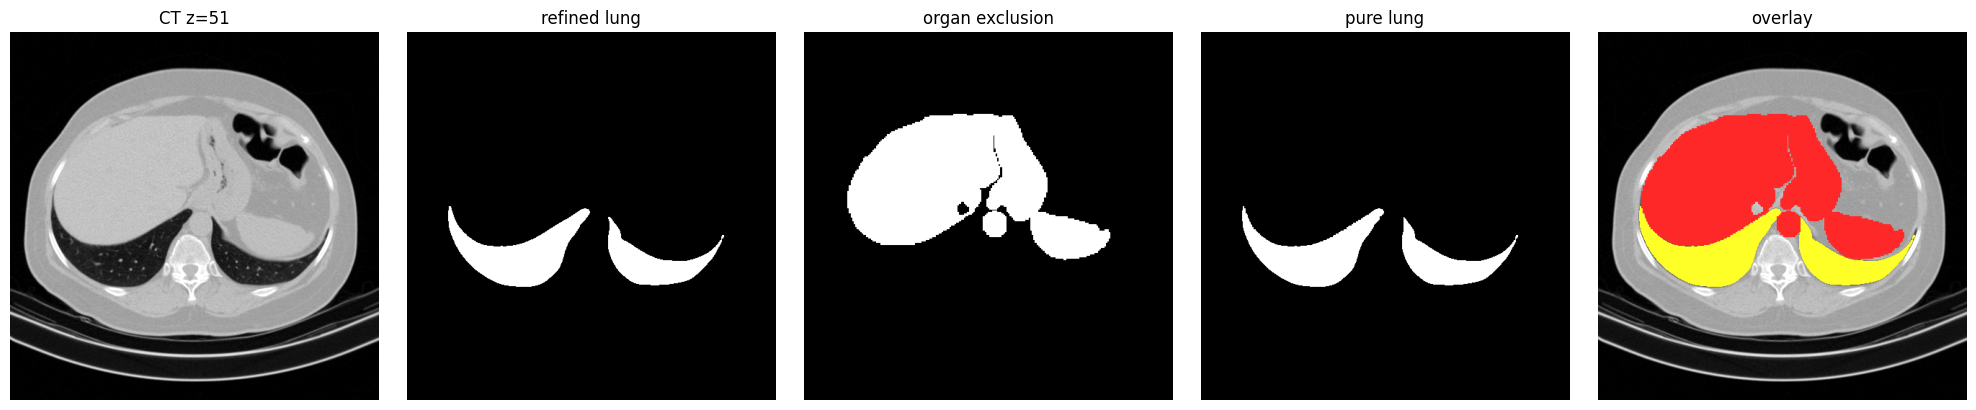

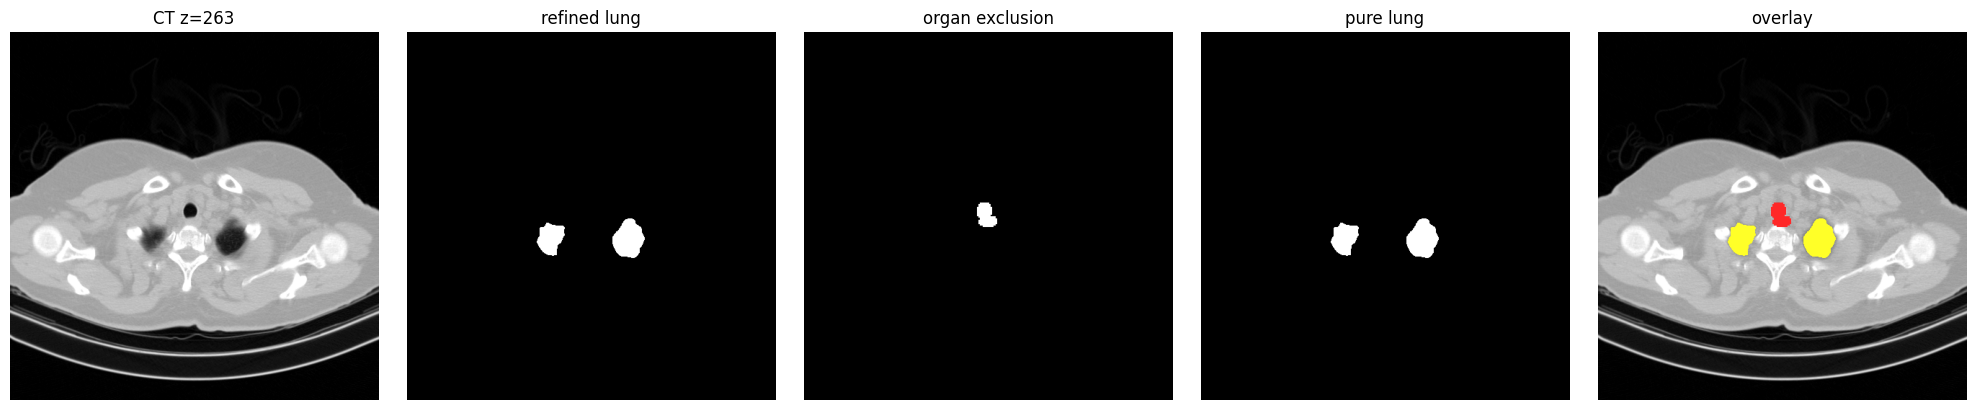

In [1]:
# ============================================================
# Test 6. Visual inspection with matplotlib
# ============================================================

import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

OUT_ROOT = Path(r"E:\jyp\ct_data_2d_preprocessed\Normal_Cases_final_v1_nonfast_test")
slice_df = pd.read_csv(OUT_ROOT / "metadata_slices.csv")

# valid slice flag가 없으면 즉석에서 만듦
MIN_PURE_LUNG_AREA_RATIO = 0.01
slice_df["is_valid_lung_slice_test"] = (
    slice_df["pure_lung_area_ratio"] >= MIN_PURE_LUNG_AREA_RATIO
).astype(int)

patient_ids = sorted(slice_df["patient_id"].unique())
patient_id = random.choice(patient_ids)

pdf = slice_df[
    (slice_df["patient_id"] == patient_id)
    & (slice_df["is_valid_lung_slice_test"] == 1)
].copy()

if len(pdf) == 0:
    raise RuntimeError(f"{patient_id}: valid lung slice가 없음.")

# pure lung 면적이 큰 순서에서 위/중간/아래 느낌으로 5장 선택
pdf = pdf.sort_values("pure_lung_area", ascending=False)
sample_indices = np.linspace(0, len(pdf) - 1, min(5, len(pdf))).astype(int)
sample_rows = pdf.iloc[sample_indices]

print("Selected patient:", patient_id)
print("Selected slice indices:", sample_rows["slice_index"].tolist())

for _, row in sample_rows.iterrows():
    z = int(row["slice_index"])

    ct = np.array(Image.open(row["slice_png"]))
    lung = np.array(Image.open(row["lung_png"]))
    organ = np.array(Image.open(row["organ_exclusion_png"]))
    pure = np.array(Image.open(row["pure_lung_png"]))
    overlay = np.array(Image.open(row["overlay_png"]))

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(ct, cmap="gray")
    axes[0].set_title(f"CT z={z}")

    axes[1].imshow(lung, cmap="gray")
    axes[1].set_title("refined lung")

    axes[2].imshow(organ, cmap="gray")
    axes[2].set_title("organ exclusion")

    axes[3].imshow(pure, cmap="gray")
    axes[3].set_title("pure lung")

    axes[4].imshow(overlay)
    axes[4].set_title("overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()